# Overall Summary

## Setup

Load [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension. 
This enables us to modify `.py` source files and reintegrate them into the notebook.


In [1]:
%load_ext autoreload
%autoreload 2

Import libraries.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.stats import linregress
import pingouin as pg

from questionnaires import load_survey_results
from pedestrian_stats import build_pedestrian_task_results, crosswalk_statistics
from behavior_tasks import build_behavioral_task_results

Build dataframe

In [4]:
df = load_survey_results(test = True)
# TODO: 데이터 부족으로 인한 임시방편. 향후 현실적인 데이터로 대체.
df.loc[3, "subj_id"] = 502
df.loc[4, "subj_id"] = 1
subj_ids = df["subj_id"].to_list()

df = build_pedestrian_task_results(df, subj_ids)
df = build_behavioral_task_results(df, subj_ids)

df.head()


Total Subjects: 3 ([100, 101, 102])
reversing BIS_1: [2, 4, 4] => [3, 1, 1]
reversing STAI_1: [4, 4, 4] => [1, 1, 1]
reversing CES-D_4: [4, 3, 2] => [1, 2, 3]


,subj_id,age,gender,school_year,BIS,BIS_motor,BIS_nonplanning,BIS_attentional,STAI,STAI_S,...,action_Nothing_cnt,action_UP_cnt,action_DOWN_cnt,action_RIGHT_cnt,action_LEFT_cnt,visited_tile_cnt_mean,visited_unique_tile_cnt_mean,visited_tile_unique_ratio_mean,DDT_mean_log_k,CRA_mean_alpha
0,100,29,2,16,77,30,25,22,96,45,...,404,138,0,650,656,53.962963,18.148148,0.344531,-6.945853,0.851175
1,502,1001,2,12,79,31,25,23,104,51,...,26,2030,48,348,569,29.520000,28.070000,0.957723,-4.945853,0.751175
2,1,1901,1,1234,80,36,24,20,109,56,...,26,2030,48,348,569,29.520000,28.070000,0.957723,-2.945853,1.111751


Utils

In [5]:
def print_summary(data, name):
    print(f"{name}: mean = {data.mean():.2f}, std = {data.std():.2f} (min={data.min()} ~ max={data.max()})")

def plot_summary(plot, data, title, bins=10):
    plot.hist(data, bins=bins, edgecolor="black")
    plot.set_xlabel(title)
    plot.set_ylabel("Frequency")
    plot.set_title(title)

def scatter_plot_with_line_regression(plot, x, y, xlabel, ylabel, title):
    plot.scatter(x, y)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept
    plot.plot(line_x, line_y, color="red")

    plot.set_xlabel(xlabel)
    plot.set_ylabel(ylabel)
    plot.set_title(f"{title}\nr={r_value:.3f}")

## Survey

### Demographics

Age: mean = 977.00, std = 936.23 (min=29 ~ max=1901)
2 males & 1 females


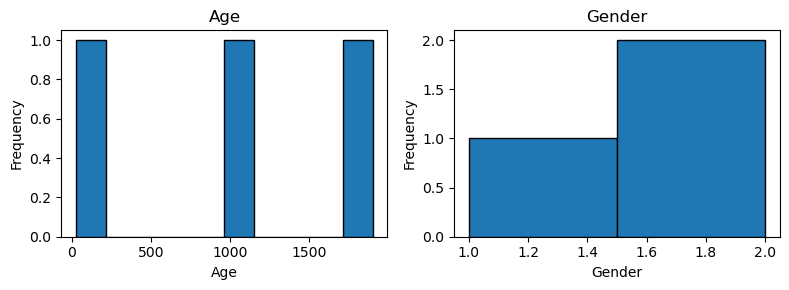

In [6]:
print_summary(df["age"], "Age")
print(f"{len(df[df['gender'] == 2])} males & {len(df[df['gender'] == 1])} females")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_summary(axes[0], df["age"], "Age")
plot_summary(axes[1], df["gender"], "Gender", bins=2)
plt.tight_layout()
plt.show()

### BIS

BIS: mean = 78.67, std = 1.53 (min=77 ~ max=80)
BIS_motor: mean = 32.33, std = 3.21 (min=30 ~ max=36)
BIS_nonplanning: mean = 24.67, std = 0.58 (min=24 ~ max=25)
BIS_attentional: mean = 21.67, std = 1.53 (min=20 ~ max=23)


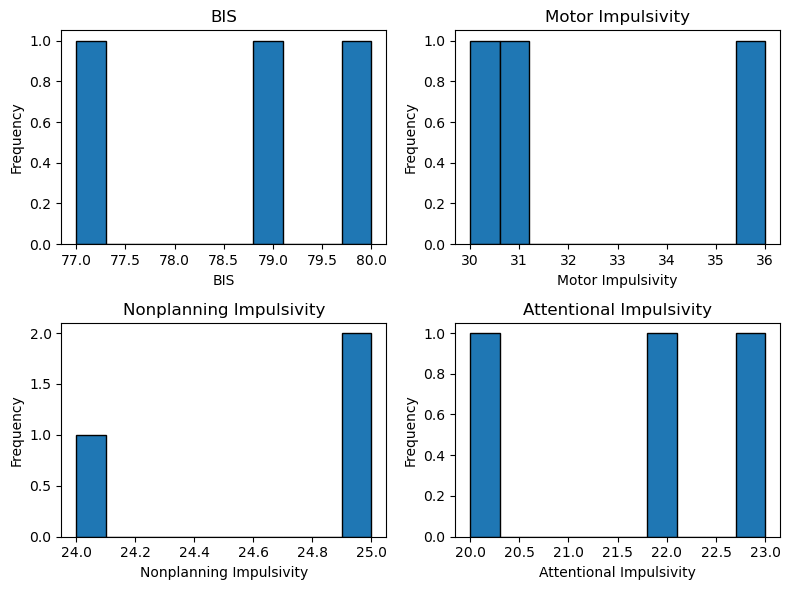

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for i in range(4):
    col = ["BIS", "BIS_motor", "BIS_nonplanning", "BIS_attentional"][i]
    title = ["BIS", "Motor Impulsivity", "Nonplanning Impulsivity", "Attentional Impulsivity"][i]
    print_summary(df[col], col)
    plot_summary(axes[i // 2, i % 2], df[col], title)
plt.tight_layout()
plt.show()

### STAI

STAI: mean = 103.00, std = 6.56 (min=96 ~ max=109)
STAI_S: mean = 50.67, std = 5.51 (min=45 ~ max=56)
STAI_T: mean = 52.33, std = 1.15 (min=51 ~ max=53)


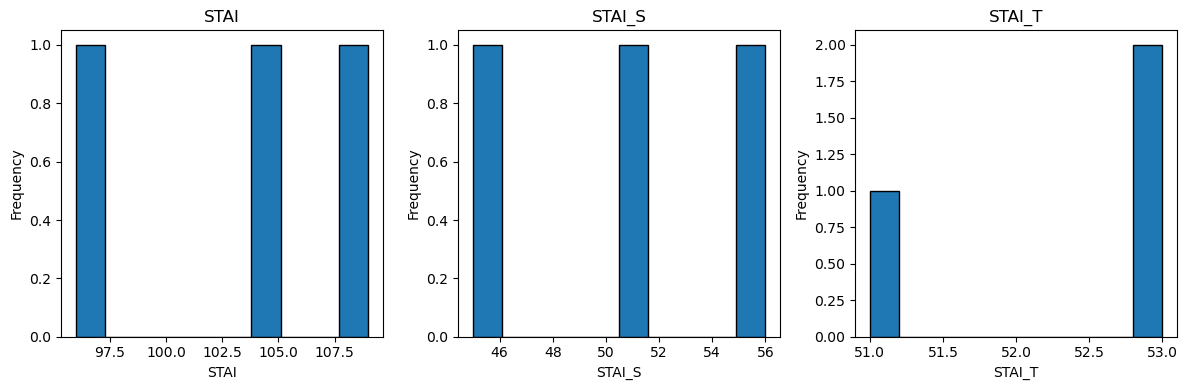

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    col = ["STAI", "STAI_S", "STAI_T"][i]
    print_summary(df[col], col)
    plot_summary(axes[i], df[col], col)
plt.tight_layout()
plt.show()

### DOSPERT

DOSPERT: mean = 106.33, std = 16.20 (min=96 ~ max=125)
DOSPERT_ETH: mean = 18.33, std = 5.51 (min=13 ~ max=24)
DOSPERT_FIN: mean = 22.67, std = 3.79 (min=20 ~ max=27)
DOSPERT_HEA: mean = 22.00, std = 4.36 (min=17 ~ max=25)
DOSPERT_REC: mean = 22.67, std = 3.21 (min=19 ~ max=25)
DOSPERT_SOC: mean = 20.67, std = 4.16 (min=16 ~ max=24)


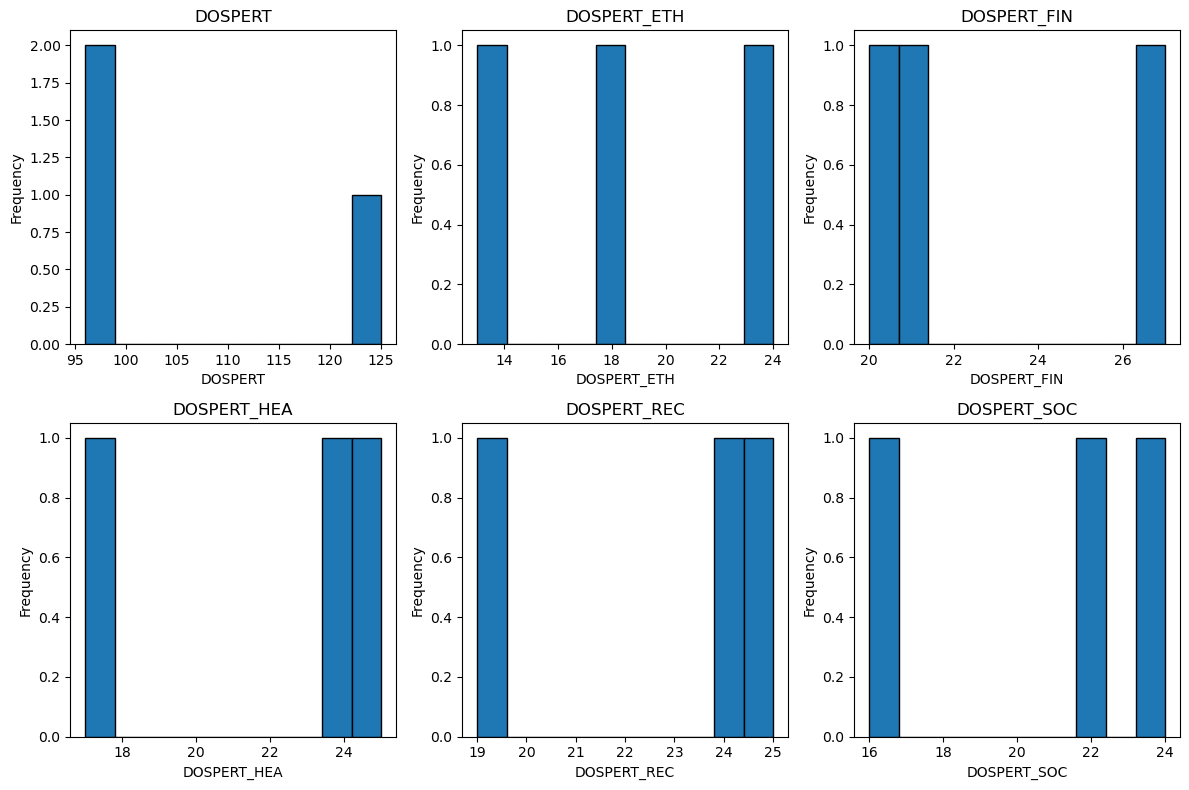

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = ["DOSPERT", "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"][i]
    title = ["DOSPERT", "Ethical Risk Taking", "Financial Risk Taking", "Health and Safety Risk Taking", "Recreational Risk Taking", "Social Risk Taking"][i]
    print_summary(df[col], col)
    plot_summary(axes[i // 3, i % 3], df[col], col)
plt.tight_layout()
plt.show()

### CES-D

CES-D: mean = 53.00, std = 0.00 (min=53 ~ max=53)


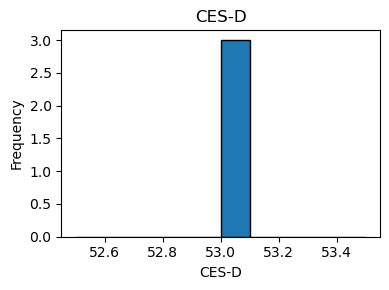

In [10]:
print_summary(df["CES_D"], "CES-D")
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
plot_summary(axes, df["CES_D"], "CES-D")
plt.tight_layout()
plt.show()

## Traditional Behavior Tasks

DDT - Discounting Rate (log k): mean = -4.95, std = 2.00 (min=-6.945852756500244 ~ max=-2.945852756500244)
CRA - Risk Preference (alpha): mean = 0.90, std = 0.19 (min=0.7511751294136046 ~ max=1.111751294136047)


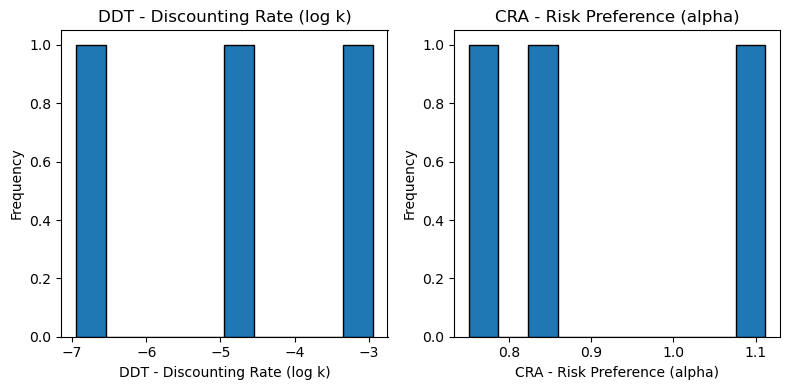

In [11]:
print_summary(df["DDT_mean_log_k"], "DDT - Discounting Rate (log k)")
print_summary(df["CRA_mean_alpha"], "CRA - Risk Preference (alpha)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_summary(axes[0], df["DDT_mean_log_k"], "DDT - Discounting Rate (log k)")
plot_summary(axes[1], df["CRA_mean_alpha"], "CRA - Risk Preference (alpha)")
plt.tight_layout()
plt.show()

## Pedestrian Task

### Scores

Total Score: mean = 125433.33, std = 102739.48 (min=6800 ~ max=184750)
Best Score: mean = 1866.67, std = 404.15 (min=1400 ~ max=2100)
Mean Score: mean = 1315.62, std = 921.25 (min=251.85185185185185 ~ max=1847.5)
STD Score: mean = 391.94, std = 5.86 (min=385.1776516905198 ~ max=395.3246332529326)


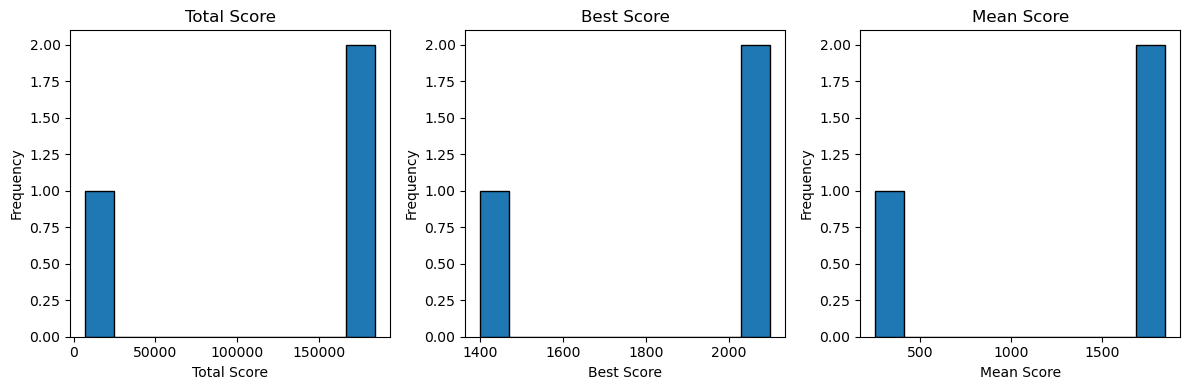

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    col = ["total_score_full", "best_score_full", "average_score_full"][i]
    title = ["Total Score", "Best Score", "Mean Score"][i]
    print_summary(df[col], title)
    plot_summary(axes[i], df[col], title)
print_summary(df['std_score_full'], "STD Score")
plt.tight_layout()
plt.show()

### Split-half Reliability
"The split-half reliability between the scores in the first half and the second half of the task assessed by the intraclass correlation coefficient (Koo & Li, 2016) was .72, which is acceptable." (Lee et al., 2014)

In [16]:
print_summary(df['total_score_session1'], "Total Score (Session 1")
print_summary(df['total_score_session2'], "Total Score (Session 2)")

total_length = len(df["subj_id"])
df_total = pd.DataFrame({
    'subject': np.repeat(df['subj_id'].values, 2),
    'rater':   np.tile(['first', 'second'], total_length),
    'score':   np.concatenate([df['total_score_session1'].values, df['total_score_session2'].values])
})
icc_table = pg.intraclass_corr(data=df_total, targets='subject', raters='rater', ratings='score')
icc_table

Total Score (Session 1: mean = 66183.33, std = 51817.19 (min=6350 ~ max=96100)
Total Score (Session 2): mean = 59250.00, std = 50922.29 (min=450 ~ max=88650)
Score Mean (Session 1): mean = 1362.74, std = 968.66 (min=244.23076923076923 ~ max=1922.0)
Score Mean (Session 2): mean = 1332.00, std = 763.83 (min=450 ~ max=1773)


,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,-0.477819,0.353345,2,3,0.728119,"[-0.96, 0.87]"
1,ICC2,Single random raters,-1.340942,0.235723,2,2,0.809243,"[-2.92, 0.86]"
2,ICC3,Single fixed raters,-0.618486,0.235723,2,2,0.809243,"[-0.99, 0.8]"
3,ICC1k,Average raters absolute,-1.830093,0.353345,2,3,0.728119,"[-44.41, 0.93]"
4,ICC2k,Average random raters,7.866104,0.235723,2,2,0.809243,"[3.04, 0.92]"
5,ICC3k,Average fixed raters,-3.242276,0.235723,2,2,0.809243,"[-164.45, 0.89]"


In [17]:
print_summary(df['average_score_session1'], "Score Mean (Session 1)")
print_summary(df['average_score_session2'], "Score Mean (Session 2)")

total_length = len(df["subj_id"])
df_total = pd.DataFrame({
    'subject': np.repeat(df['subj_id'].values, 2),
    'rater':   np.tile(['first', 'second'], total_length),
    'score':   np.concatenate([df['average_score_session1'].values, df['average_score_session2'].values])
})
icc_table = pg.intraclass_corr(data=df_total, targets='subject', raters='rater', ratings='score')
icc_table

Score Mean (Session 1): mean = 1362.74, std = 968.66 (min=244.23076923076923 ~ max=1922.0)
Score Mean (Session 2): mean = 1332.00, std = 763.83 (min=450 ~ max=1773)


,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,-0.499633,0.333660,2,3,0.739876,"[-0.96, 0.86]"
1,ICC2,Single random raters,-1.386893,0.223072,2,2,0.817614,"[-2.9, 0.85]"
2,ICC3,Single fixed raters,-0.635227,0.223072,2,2,0.817614,"[-0.99, 0.79]"
3,ICC1k,Average raters absolute,-1.997066,0.333660,2,3,0.739876,"[-47.09, 0.92]"
4,ICC2k,Average random raters,7.169385,0.223072,2,2,0.817614,"[3.05, 0.92]"
5,ICC3k,Average fixed raters,-3.482863,0.223072,2,2,0.817614,"[-173.83, 0.89]"


### Crosswalk usage
- TODO

### Game over status
- TODO

### Locomotor Statistics
- Action Proportions
- Number of visited tiles